# Final Model Evaluation Using the Saved weights 
Authors:
Mohammed Abdulai
Peter Mvuma

# Libraries

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Data Preprocessing

In [2]:
# Run the sanity check
root = r"C:/Users/amysh/Desktop/AI_Project/covid19"

for cls in os.listdir(root):
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    imgs = set(os.listdir(img_dir))
    masks = set(os.listdir(msk_dir))

    print(f"{cls}: images={len(imgs)}, masks={len(masks)}")

    missing = imgs - masks
    extra = masks - imgs

    if missing:
        print("  ❌ Missing masks:", list(missing)[:5])
    if extra:
        print("  ❌ Extra masks:", list(extra)[:5])


COVID: images=3616, masks=3616
Lung_Opacity: images=6012, masks=6012
Normal: images=10192, masks=10192
Viral_Pneumonia: images=1345, masks=1345


# Build the indexed dataset (image–mask–label)

In [3]:
import glob

class_names = sorted(os.listdir(root))
class_to_idx = {c:i for i,c in enumerate(class_names)}

records = []

for cls in class_names:
    img_dir = os.path.join(root, cls, "images")
    msk_dir = os.path.join(root, cls, "masks")

    for img_path in sorted(glob.glob(img_dir + "\\*")):
        fname = os.path.basename(img_path)
        mask_path = os.path.join(msk_dir, fname)

        if os.path.exists(mask_path):
            records.append((img_path, mask_path, class_to_idx[cls]))

records = np.array(records, dtype=object)

print("Total samples:", len(records))
print("Class distribution:")
for c,i in class_to_idx.items():
    print(c, np.sum(records[:,2] == i))


Total samples: 21165
Class distribution:
COVID 3616
Lung_Opacity 6012
Normal 10192
Viral_Pneumonia 1345


# Stratified 70 / 15 / 15 split (Windows-safe)

In [4]:
X = records[:, :2]     # image_path, mask_path
y = records[:, 2].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))


Train: 14815
Val:   3175
Test:  3175


# Define class names

In [12]:
class_names = ["COVID", "Lung_Opacity", "Normal", "Viral_Pneumonia"]
NUM_CLASSES = len(class_names)


# # Multi-Task with Segmentation

Multi-Task DenseNet Model

We build the multitask model on the best weights from the baseline fine-tuned DenseNet model. This allows us to determine whether improvements in the multitasking are significant or not. So, the best weights from the baseline fine-tuned model are saved and then loaded to continue with the multitasking.

In [13]:
# Define Multi-Task Loader
IMG_SIZE = (224,224)
BATCH_SIZE = 32

def load_image_mask(img_path, mask_path, label):

    # ---- IMAGE ----
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, 3, axis=-1)

    # ---- MASK ----
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask > 127, tf.float32)

    # ---- LABEL ----
    label = tf.one_hot(label, depth=NUM_CLASSES)

    return img, (label, mask)

In [14]:
# Define Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

def augment_image(img, targets):
    label, mask = targets
    img = data_augmentation(img, training=True)
    return img, (label, mask)

In [15]:
# Multi-Task Dataset

def make_multitask_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X[:,0].tolist(), X[:,1].tolist(), y)
    )

    ds = ds.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2048, seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_multitask_dataset(X_train, y_train, training=True)
val_ds   = make_multitask_dataset(X_val,   y_val,   training=False)
test_ds  = make_multitask_dataset(X_test,  y_test,  training=False)

In [16]:
# Sanity Checks
for imgs, (labels, masks) in train_ds.take(1):
    print("Images:", imgs.shape)
    print("Labels:", labels.shape)
    print("Masks: ", masks.shape)

Images: (32, 224, 224, 3)
Labels: (32, 4)
Masks:  (32, 224, 224, 1)


# Define Multi-Task DenseNet

In [17]:
def build_multitask_densenet(img_shape=(224,224,3), num_classes=4):

    inputs = keras.Input(shape=img_shape)

    # Shared Encoder 
    backbone = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Feature map from backbone
    x = backbone.output  # (7,7,1024)
    
    # CLASSIFICATION HEAD
    cls = layers.GlobalAveragePooling2D()(x)
    cls = layers.Dense(512, activation="relu")(cls)
    cls = layers.BatchNormalization()(cls)
    cls = layers.Dropout(0.30)(cls)
    cls_out = layers.Dense(
        num_classes,
        activation="softmax",
        name="classification"
    )(cls)


    # SEGMENTATION HEAD
    seg = layers.Conv2D(256, 3, padding="same", activation="relu")(x)

    # 7 → 14 → 28 → 56 → 112 → 224
    for f in [128, 64, 32, 16]:
        seg = layers.UpSampling2D(size=(2,2))(seg)
        seg = layers.Conv2D(f, 3, padding="same", activation="relu")(seg)

    seg = layers.UpSampling2D(size=(2,2))(seg)

    seg_out = layers.Conv2D(
        1, 1,
        activation="sigmoid",
        name="segmentation"
    )(seg)

    model = keras.Model(
        inputs=inputs,
        outputs={
            "classification": cls_out,
            "segmentation": seg_out
        },
        name="MultiTask_DenseNet"
    )

    return model, backbone

In [18]:
# Build Multi-Task DenseNet
multitask_model, backbone = build_multitask_densenet(
    img_shape=(224,224,3),
    num_classes=NUM_CLASSES
)

In [19]:
# Compile
multitask_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "classification": "categorical_crossentropy",
        "segmentation": "binary_crossentropy"
    },
    loss_weights={
        "classification": 1.0,
        "segmentation": 0.1
    },
    metrics={"classification": ["accuracy"]}
)

# Importing the final model saved weights

In [20]:
phase1_5_path = r"C:\Users\amysh\Desktop\AI_Project\DenseNet\checkpoints\multitask_phase1_5_best.weights.h5"
multitask_model.load_weights(phase1_5_path)

C:\Users\amysh\anaconda3.0\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Evaluation

In [21]:
results = multitask_model.evaluate(test_ds, verbose=1, return_dict=True)

print("\n=== Evaluation Results ===")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - classification_accuracy: 0.9184 - classification_loss: 0.2430 - loss: 0.2523 - segmentation_loss: 0.1145

=== Evaluation Results ===
classification_accuracy: 0.9184
classification_loss: 0.2430
loss: 0.2523
segmentation_loss: 0.1145


In [22]:
# Get predictions

preds = multitask_model.predict(test_ds)

probs = preds["classification"]
y_pred = probs.argmax(axis=1)

y_true = np.concatenate(
    [y.numpy().argmax(axis=1) for _, (y, _) in test_ds],
    axis=0
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step


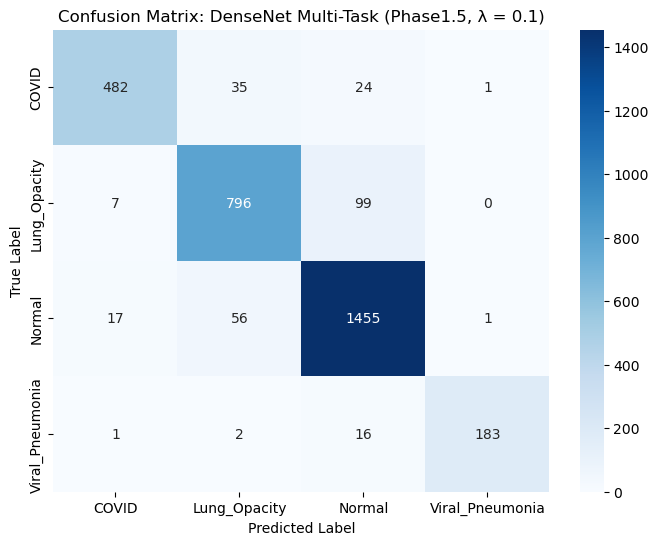

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: DenseNet Multi-Task (Phase1.5, λ = 0.1)")
plt.show()

In [24]:
# RoC-AuC Score
y_true_oh = label_binarize(y_true, classes=range(NUM_CLASSES))
print("Macro AUC:", roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovr"))

Macro AUC: 0.9862838088096681


In [25]:
# Binarize labels for multiclass ROC
num_classes = probs.shape[1]

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

In [26]:
# Compute ROC & AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [27]:
# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

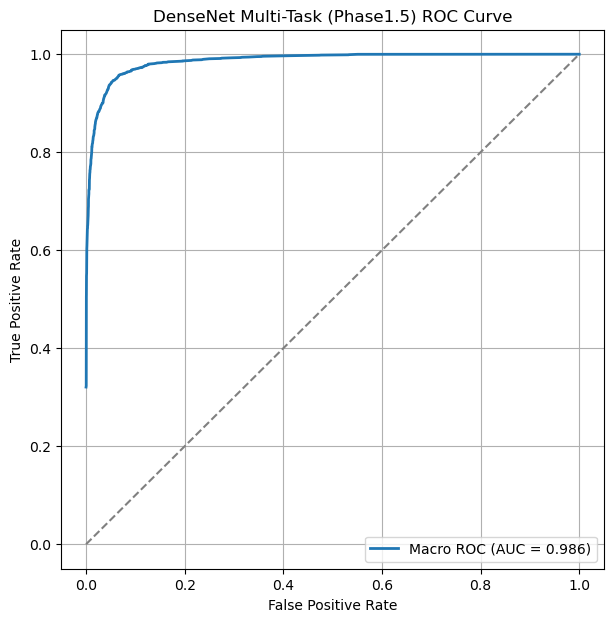

In [28]:
# Plot ROC curve
plt.figure(figsize=(7,7))
plt.plot(all_fpr, mean_tpr,
         label=f"Macro ROC (AUC = {macro_auc:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet Multi-Task (Phase1.5) ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Dice and IoU

In [29]:
def dice_iou_per_batch(y_true, y_pred, eps=1e-7):
    # y_true, y_pred shape: (B, H, W, 1)
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    intersection = np.sum(y_true * y_pred, axis=(1, 2, 3))
    sum_true = np.sum(y_true, axis=(1, 2, 3))
    sum_pred = np.sum(y_pred, axis=(1, 2, 3))
    union = sum_true + sum_pred - intersection

    dice = (2.0 * intersection + eps) / (sum_true + sum_pred + eps)
    iou = (intersection + eps) / (union + eps)
    return dice, iou

dice_scores = []
iou_scores = []

threshold = 0.5

for imgs, (_, true_masks) in test_ds:
    preds = multitask_model.predict(imgs, verbose=0)
    pred_masks = preds["segmentation"]

    pred_masks_bin = (pred_masks >= threshold).astype(np.float32)
    true_masks_bin = (true_masks.numpy() >= 0.5).astype(np.float32)

    dice_b, iou_b = dice_iou_per_batch(true_masks_bin, pred_masks_bin)
    dice_scores.extend(dice_b.tolist())
    iou_scores.extend(iou_b.tolist())

dice_scores = np.array(dice_scores)
iou_scores = np.array(iou_scores)

print(f"Mean Dice: {dice_scores.mean():.4f}")
print(f"Mean IoU : {iou_scores.mean():.4f}")
print(f"Dice std : {dice_scores.std():.4f}")
print(f"IoU std  : {iou_scores.std():.4f}")

Mean Dice: 0.8865
Mean IoU : 0.8021
Dice std : 0.0698
IoU std  : 0.0963


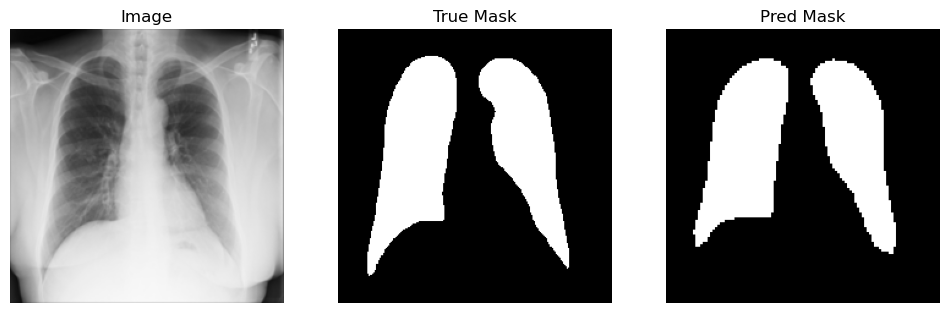

In [30]:
for imgs, (_, true_masks) in test_ds.take(1):
    preds = multitask_model.predict(imgs, verbose=0)
    pred_masks = preds["segmentation"]

    idx = 0
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(imgs[idx].numpy())
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true_masks[idx].numpy().squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow((pred_masks[idx] >= 0.5).astype(np.float32).squeeze(), cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")

    plt.show()
    break

# Grad-CAM

In [37]:
for layer in multitask_model.layers:
    if layer.name == "relu":
        print("Found:", layer.name, layer.output.shape)

Found: relu (None, 7, 7, 1024)


In [40]:
import cv2
def overlay_gradcam(image, heatmap, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image
    """

    # Ensure image is uint8
    if image.max() <= 1.0:
        image = (image * 255).astype(np.uint8)
    else:
        image = image.astype(np.uint8)

    # Convert heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)

    return overlay

In [41]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output["classification"]
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy(), int(pred_index)

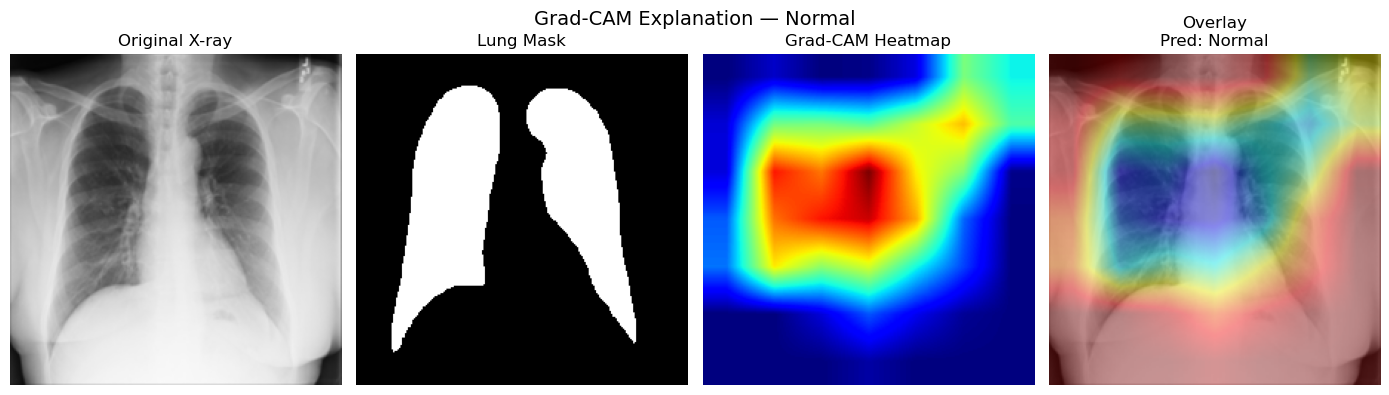

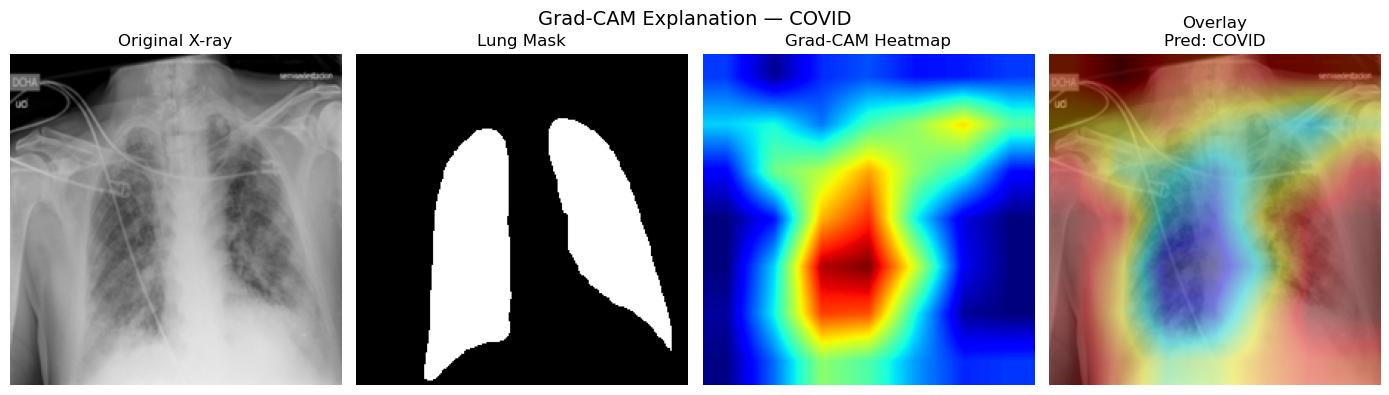

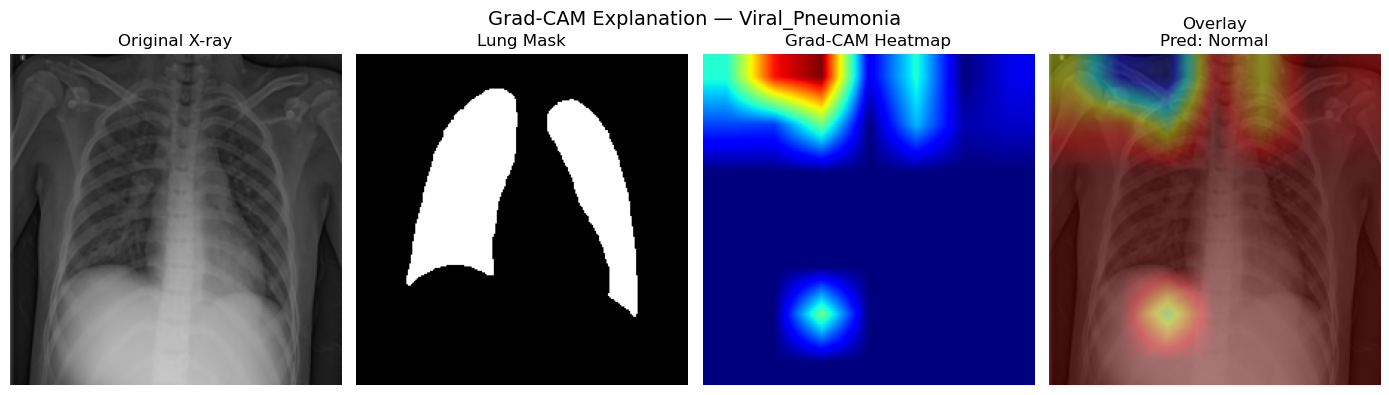

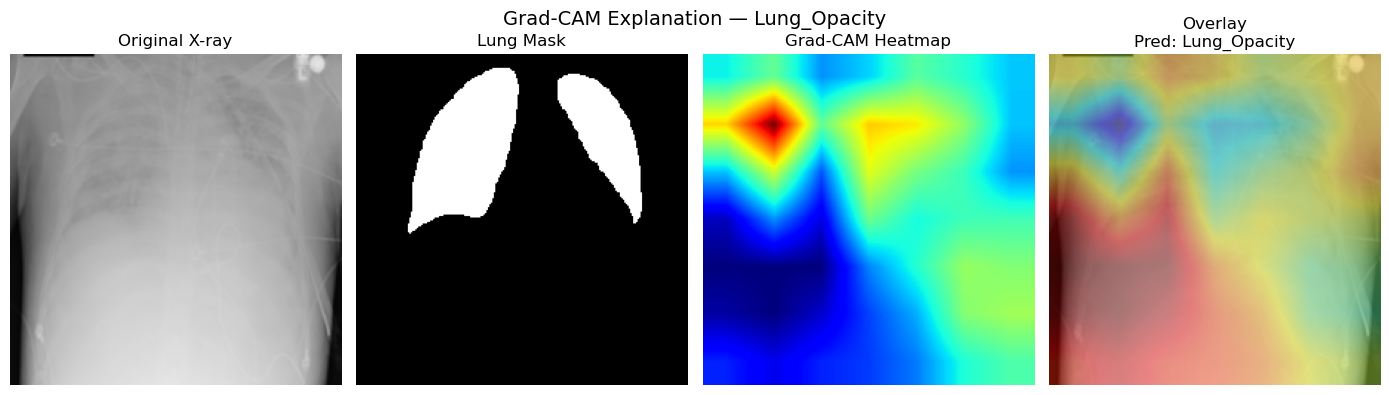

In [42]:
samples = {}

# Collect one image per class
for imgs, (labels, masks) in test_ds:

    for i in range(imgs.shape[0]):

        label = np.argmax(labels[i].numpy())

        if label not in samples:
            samples[label] = (imgs[i].numpy(), masks[i].numpy())

        if len(samples) == len(class_names):
            break

    if len(samples) == len(class_names):
        break


# Generate Grad-CAM for each class
for label, (img, true_mask) in samples.items():

    img_array = np.expand_dims(img, axis=0)

    heatmap, pred_class = make_gradcam_heatmap(
        img_array,
        multitask_model,
        last_conv_layer_name="relu"
    )

    # Smooth heatmap
    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        (224,224)
    ).numpy().squeeze()

    overlay_img = overlay_gradcam(img, heatmap)

    plt.figure(figsize=(14,4))

    # Original image
    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original X-ray")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(1,4,2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

    # Grad-CAM heatmap
    plt.subplot(1,4,3)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    # Overlay
    plt.subplot(1,4,4)
    plt.imshow(overlay_img)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.suptitle(f"Grad-CAM Explanation — {class_names[label]}", fontsize=14)

    plt.tight_layout()

    # Save for report
    plt.savefig(f"gradcam_{class_names[label]}.png", dpi=300, bbox_inches="tight")

    plt.show()